# Experiments
## Full Experimental Suite - 4 Experiments

Theo định hướng nghiên cứu, thực hiện 4 thí nghiệm:
1. **Baseline Comparison**: LR+TF-IDF vs RoBERTa
2. **Domain Adaptation**: RoBERTa general vs RoBERTa fine-tuned
3. **Calibration**: RoBERTa vs RoBERTa + Temperature Scaling (ECE, Brier)
4. **Uncertainty + LLM Hybrid**: RoBERTa vs MC Dropout vs Hybrid System

> **[WARNING] Prerequisites**: Chạy notebook 02 (preprocessing), 03 (baseline), 04 (RoBERTa training) trước.
>
> **[INFO] CPU vs GPU**:
> - Experiments 1-3: Chạy nhanh trên CPU (< 5 phút)
> - Experiment 4 (MC Dropout): Khuyến nghị GPU, nhưng có thể chạy CPU (chậm hơn ~6x)
> - Nếu chạy CPU, có thể giảm MC_DROPOUT_RUNS từ 10 xuống 5 để nhanh hơn


##  Setup cho Google Colab

**Trước khi chạy notebook này trên Colab:**

1. Upload file `Fake_news_RoBERTa.zip` lên Google Drive
2. Chạy cell dưới để mount Drive và giải nén
3. Chọn GPU runtime: Runtime -> Change runtime type -> GPU (T4)


In [1]:
# ============================================================
# COLAB SETUP - Chay cell nay TRUOC TIEN neu dung Colab
# ============================================================
import os
import sys
import zipfile

# Check if running on Colab
try:
    from google.colab import drive
    IN_COLAB = True
    print('[OK] Running on Google Colab')
except:
    IN_COLAB = False
    print('Running locally (not Colab)')

if IN_COLAB:
    # Mount Google Drive
    print('\nMounting Google Drive...')
    drive.mount('/content/drive')
    
    # TODO: Thay doi path nay neu ban dat file zip o cho khac
    ZIP_PATH = '/content/drive/MyDrive/Fake_news_RoBERTa.zip'
    EXTRACT_DIR = '/content/project'
    
    if os.path.exists(ZIP_PATH):
        print(f'\n[OK] Found zip file: {ZIP_PATH}')
        print(f'  Size: {os.path.getsize(ZIP_PATH) / 1e6:.1f} MB')
        
        # Clean old extraction
        if os.path.exists(EXTRACT_DIR):
            import shutil
            shutil.rmtree(EXTRACT_DIR)
            print('  Cleaned old extraction.')
        
        # Extract using Python zipfile (handles backslash paths from Windows)
        print('\nExtracting files...')
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            for info in zf.infolist():
                # Fix Windows backslash paths
                info.filename = info.filename.replace('\\', '/')
                zf.extract(info, EXTRACT_DIR)
        print('[OK] Extraction complete.')
        
        # Set PROJECT_ROOT
        PROJECT_ROOT = EXTRACT_DIR
        
        # Setup Python path
        if PROJECT_ROOT not in sys.path:
            sys.path.insert(0, PROJECT_ROOT)
        
        # Change working directory to simulate running from notebooks/
        notebooks_dir = os.path.join(PROJECT_ROOT, 'notebooks')
        if os.path.exists(notebooks_dir):
            os.chdir(notebooks_dir)
        
        # Verify essential files
        print(f'\n[OK] Project root: {PROJECT_ROOT}')
        print('\nVerifying files...')
        
        essential_files = [
            'src/config.py',
            'data/processed/train.csv',
            'data/processed/test.csv',
        ]
        generated_files = [
            'models/roberta/config.json',
            'models/roberta/model.safetensors',
            'models/baseline/lr_model.pkl',
            'results/baseline_results.json',
            'results/roberta_results.json',
        ]
        
        all_ok = True
        print('  Essential files:')
        for f in essential_files:
            path = os.path.join(PROJECT_ROOT, f)
            exists = os.path.exists(path)
            status = '[OK]' if exists else '[MISSING]'
            print(f'    {status} {f}')
            if not exists:
                all_ok = False
        
        print('  Generated files (from training):')
        for f in generated_files:
            path = os.path.join(PROJECT_ROOT, f)
            exists = os.path.exists(path)
            status = '[OK]' if exists else '[NOT YET]'
            print(f'    {status} {f}')
        
        if all_ok:
            print('\n[OK] All essential files ready! You can proceed.')
            missing_gen = [f for f in generated_files if not os.path.exists(os.path.join(PROJECT_ROOT, f))]
            if missing_gen:
                print('[INFO] Some generated files are missing.')
                print('  Run notebooks 03 (baseline) and 04 (RoBERTa training) first.')
                print('  Or rebuild the zip with models/ and results/ included.')
            else:
                print('[OK] All generated files also found!')
        else:
            print('\n[ERROR] Essential files are missing. Check your zip file.')
    else:
        print(f'\n[ERROR] Zip file not found: {ZIP_PATH}')
        print('\nPlease:')
        print('  1. Upload Fake_news_RoBERTa.zip to Google Drive (root of MyDrive)')
        print('  2. Update ZIP_PATH variable above if you put it in a different location')
        print('  3. Re-run this cell')
else:
    print('\nSkipping Colab setup (running locally)')
    PROJECT_ROOT = os.path.abspath('..')


Mounted at /content/drive

[OK] Found zip file: /content/drive/MyDrive/Fake_news_RoBERTa.zip
  Size: 597.4 MB

Extracting files...
[OK] Extraction complete.

[OK] Project root: /content/project

Verifying files...
  Essential files:
    [OK] src/config.py
    [OK] data/processed/train.csv
    [OK] data/processed/test.csv
  Generated files (from training):
    [OK] models/roberta/config.json
    [OK] models/roberta/model.safetensors
    [OK] models/baseline/lr_model.pkl
    [OK] results/baseline_results.json
    [OK] results/roberta_results.json

[OK] All essential files ready! You can proceed.
[OK] All generated files also found!


In [2]:
# CELL 1: Setup Path
import sys
import os

# Use PROJECT_ROOT from Colab setup if available
try:
    _ = PROJECT_ROOT
    print(f'Using PROJECT_ROOT from Colab setup: {PROJECT_ROOT}')
except NameError:
    # Running locally from notebooks/ folder
    PROJECT_ROOT = os.path.abspath('..')
    print(f'Running locally, PROJECT_ROOT: {PROJECT_ROOT}')

# Add to path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
    print(f'[OK] Added to sys.path: {PROJECT_ROOT}')

# Verify
src_path = os.path.join(PROJECT_ROOT, 'src')
config_path = os.path.join(src_path, 'config.py')

print(f'\nVerification:')
print(f'  src/ exists: {os.path.exists(src_path)}')
print(f'  config.py exists: {os.path.exists(config_path)}')

if not os.path.exists(config_path):
    print('\n[ERROR] Cannot find src/config.py')
    print(f'   Looking in: {config_path}')
    print('\n   If on Colab: Run the Colab setup cell above first')
    print('   If local: Make sure you are in the notebooks/ folder')
else:
    print('\n[OK] Path setup successful!')


Using PROJECT_ROOT from Colab setup: /content/project

Verification:
  src/ exists: True
  config.py exists: True

[OK] Path setup successful!


In [3]:
# CELL 2: Import Libraries (CHẠY SAU CELL 1)
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

from src.config import *
from src.utils import set_seed, get_device, load_metrics, save_metrics
from src.dataset import FakeNewsDataset, load_data
from src.model import load_trained_model, mc_dropout_predict, enable_mc_dropout
from src.evaluation import (
    evaluate_model, print_evaluation_report, compare_models_table,
    plot_confusion_matrix, plot_roc_curve, plot_reliability_diagram,
    plot_uncertainty_distribution
)
from src.calibration import TemperatureScaling, compute_ece, compute_brier_score, calibration_report

set_seed(SEED)
device = get_device()
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'[OK] Setup complete!')
print(f'Device: {device}')
print(f'Results dir: {RESULTS_DIR}')


[OK] Using GPU: Tesla T4
  VRAM: 15.64 GB
[OK] Setup complete!
Device: cuda
Results dir: /content/project/results


## Load Models & Data


In [4]:
# Load trained RoBERTa
model, tokenizer = load_trained_model(ROBERTA_MODEL_DIR)
model.to(device)
model.eval()

# Load test data
test_df = load_data(TEST_FILE)
test_dataset = FakeNewsDataset(
    texts=test_df['text'].tolist(),
    labels=test_df['label'].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0)

# Load val data (for calibration)
val_df = load_data(VAL_FILE)
val_dataset = FakeNewsDataset(
    texts=val_df['text'].tolist(),
    labels=val_df['label'].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0)

print(f'Test samples:  {len(test_dataset):,}')
print(f'Val samples:   {len(val_dataset):,}')


Loading trained model from: /content/project/models/roberta
[OK] Model loaded successfully
[OK] Loaded 20,405 records from /content/project/data/processed/test.csv
[OK] Loaded 20,405 records from /content/project/data/processed/val.csv
Test samples:  20,405
Val samples:   20,405


---
# Experiment 1 - Baseline Comparison
So sánh **LR + TF-IDF** vs **RoBERTa** trên Accuracy và F1 Score.


In [5]:
# Load baseline results
baseline_results = load_metrics(os.path.join(RESULTS_DIR, 'baseline_results.json'))

# Get RoBERTa results
predictions, true_labels, all_probs, roberta_metrics = evaluate_model(model, test_loader, device)

# Compare
exp1_results = {
    'LR + TF-IDF': {
        'accuracy': baseline_results['accuracy'],
        'precision': baseline_results.get('precision', 0),
        'recall': baseline_results.get('recall', 0),
        'f1': baseline_results['f1']
    },
    'RoBERTa (fine-tuned)': {
        'accuracy': roberta_metrics['accuracy'],
        'precision': roberta_metrics['precision'],
        'recall': roberta_metrics['recall'],
        'f1': roberta_metrics['f1']
    }
}

print('\n=== EXPERIMENT 1: Baseline Comparison ===')
compare_models_table(exp1_results)

save_metrics(exp1_results, os.path.join(RESULTS_DIR, 'exp1_baseline_comparison.json'))


Evaluating:   0%|          | 0/638 [00:00<?, ?it/s]


=== EXPERIMENT 1: Baseline Comparison ===

  Model                            Accuracy  Precision     Recall         F1
──────────────────────────────────────────────────────────────────────
  LR + TF-IDF                        0.8926     0.8807     0.8918     0.8862
  RoBERTa (fine-tuned)               0.9204     0.8569     0.9966     0.9215

[OK] Metrics saved to: /content/project/results/exp1_baseline_comparison.json


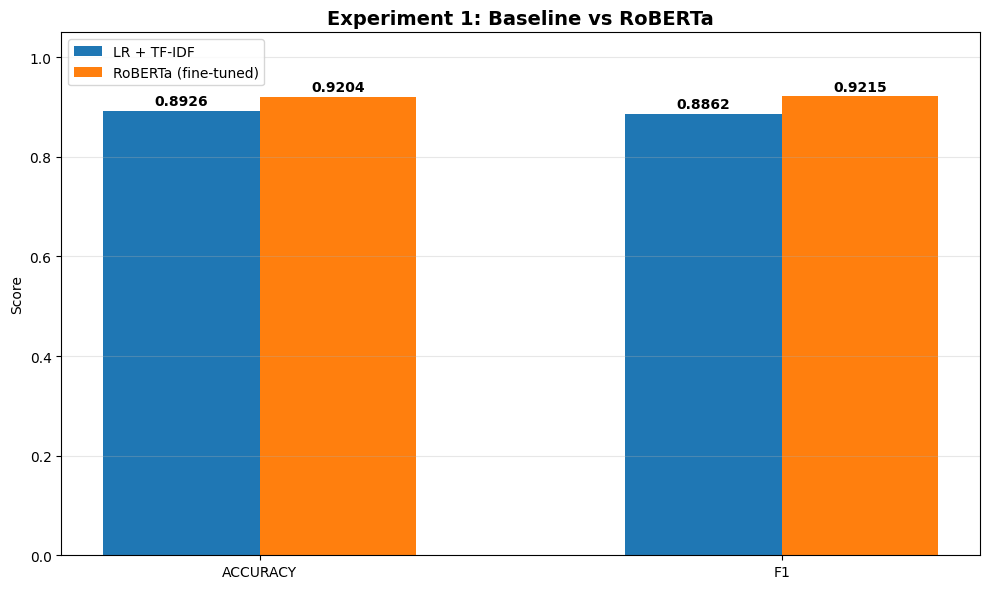

In [6]:
# Visualization: side-by-side bar chart
models = list(exp1_results.keys())
metrics_names = ['accuracy', 'f1']
x = np.arange(len(metrics_names))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
for i, m in enumerate(models):
    vals = [exp1_results[m][mn] for mn in metrics_names]
    bars = ax.bar(x + i * width, vals, width, label=m)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels([m.upper() for m in metrics_names])
ax.set_ylabel('Score')
ax.set_title('Experiment 1: Baseline vs RoBERTa', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'exp1_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()


---
# Experiment 2 - Domain Adaptation
So sánh **RoBERTa (general, pretrained)** vs **RoBERTa (fine-tuned on news domain)**.

Mục tiêu: chứng minh domain knowledge giúp tăng performance.

> **Lưu ý**: Kết quả "general" RoBERTa lấy từ zero-shot (không fine-tune).


In [7]:
# Load pretrained RoBERTa (not fine-tuned) for comparison
from src.model import load_model_and_tokenizer as load_fresh

general_model, _ = load_fresh(model_name='roberta-base', num_labels=NUM_LABELS, dropout_rate=DROPOUT_RATE)
general_model.to(device)

# Evaluate general (zero-shot) RoBERTa
gen_preds, gen_labels, gen_probs, gen_metrics = evaluate_model(general_model, test_loader, device)

exp2_results = {
    'RoBERTa (general)': {
        'accuracy': gen_metrics['accuracy'],
        'precision': gen_metrics['precision'],
        'recall': gen_metrics['recall'],
        'f1': gen_metrics['f1']
    },
    'RoBERTa (fine-tuned news)': {
        'accuracy': roberta_metrics['accuracy'],
        'precision': roberta_metrics['precision'],
        'recall': roberta_metrics['recall'],
        'f1': roberta_metrics['f1']
    }
}

print('\n=== EXPERIMENT 2: Domain Adaptation ===')
compare_models_table(exp2_results)

save_metrics(exp2_results, os.path.join(RESULTS_DIR, 'exp2_domain_adaptation.json'))

# Cleanup
del general_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None


Loading model: roberta-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[OK] Model loaded: roberta-base
  Parameters: 124,647,170 (trainable: 124,647,170)


Evaluating:   0%|          | 0/638 [00:00<?, ?it/s]


=== EXPERIMENT 2: Domain Adaptation ===

  Model                            Accuracy  Precision     Recall         F1
──────────────────────────────────────────────────────────────────────
  RoBERTa (general)                  0.4689     0.4689     1.0000     0.6384
  RoBERTa (fine-tuned news)          0.9204     0.8569     0.9966     0.9215

[OK] Metrics saved to: /content/project/results/exp2_domain_adaptation.json


---
# Experiment 3 - Calibration
So sánh **RoBERTa** vs **RoBERTa + Temperature Scaling**.

Metrics: **ECE** (Expected Calibration Error), **Brier Score**.


Before Temperature Scaling:
  ECE:   0.0122
  Brier: 0.0841
[OK] Saved: /content/project/results/exp3_reliability_before.png


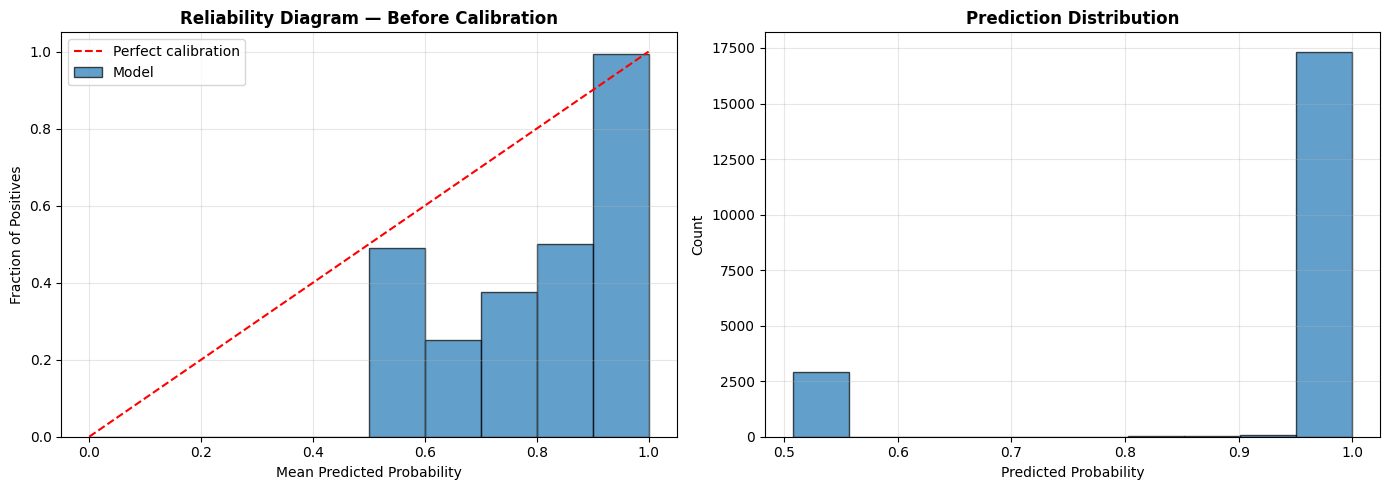

In [8]:
# Before calibration
ece_before = compute_ece(true_labels, all_probs)
brier_before = compute_brier_score(true_labels, all_probs)
print(f'Before Temperature Scaling:')
print(f'  ECE:   {ece_before:.4f}')
print(f'  Brier: {brier_before:.4f}')

# Reliability diagram before
plot_reliability_diagram(true_labels, all_probs,
    save_path=os.path.join(RESULTS_DIR, 'exp3_reliability_before.png'),
    title='Reliability Diagram — Before Calibration')


[OK] Temperature Scaling fitted: T = 1.4978

  CALIBRATION REPORT
  Metric              Before      After          Δ
───────────────────────────────────────────────────────
  ECE                 0.0122     0.0078 ↓ 0.0045
  Brier               0.0841     0.0830 ↓ 0.0011
[OK] Saved: /content/project/results/exp3_reliability_after.png


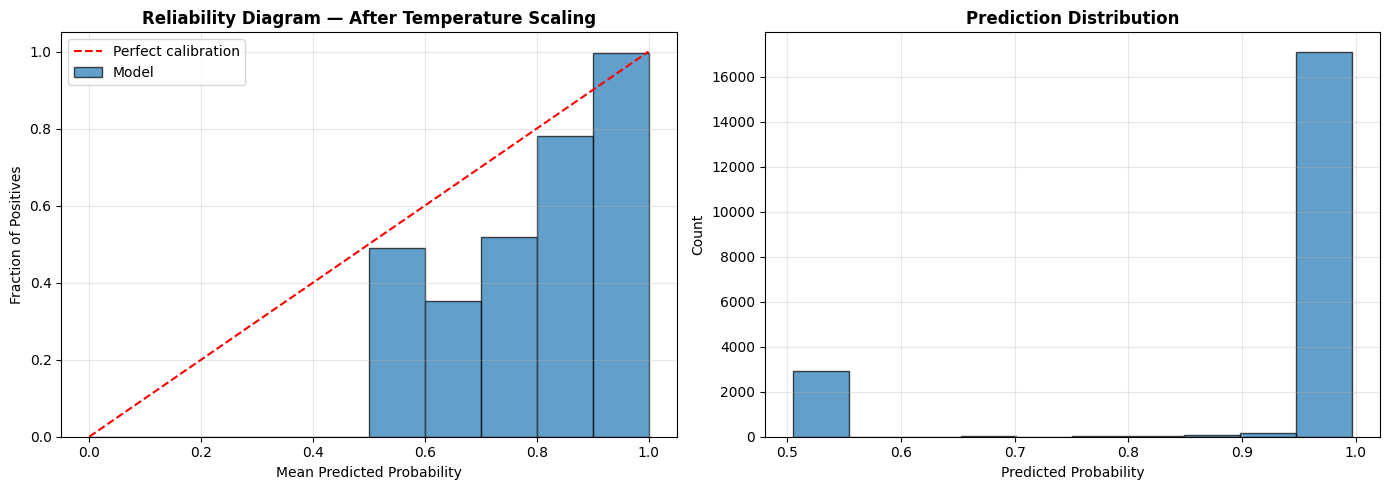

[OK] Metrics saved to: /content/project/results/exp3_calibration.json


In [9]:
# Fit Temperature Scaling on validation set
temp_scaler = TemperatureScaling()
optimal_temp = temp_scaler.fit(model, val_loader, device)

# Apply to test set logits
# Re-collect test logits
model.eval()
test_logits = []
with torch.no_grad():
    for batch in test_loader:
        outputs = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device))
        test_logits.append(outputs.logits.cpu())

test_logits = torch.cat(test_logits)

# Calibrate
calibrated_probs = temp_scaler.calibrate(test_logits.to(device)).cpu().numpy()

# After calibration metrics
calibration_report(true_labels, all_probs, calibrated_probs)

# Reliability diagram after
plot_reliability_diagram(true_labels, calibrated_probs,
    save_path=os.path.join(RESULTS_DIR, 'exp3_reliability_after.png'),
    title='Reliability Diagram — After Temperature Scaling')

# Save
exp3_results = {
    'optimal_temperature': float(optimal_temp),
    'before': {'ECE': float(ece_before), 'Brier': float(brier_before)},
    'after': {'ECE': float(compute_ece(true_labels, calibrated_probs)),
              'Brier': float(compute_brier_score(true_labels, calibrated_probs))}
}
save_metrics(exp3_results, os.path.join(RESULTS_DIR, 'exp3_calibration.json'))


---
# Experiment 4 - Uncertainty + LLM Hybrid
So sánh:
1. **RoBERTa only** (standard inference)
2. **RoBERTa + MC Dropout** (uncertainty estimation)
3. **Hybrid system** (MC Dropout + Temperature Scaling + LLM verification)

Mục tiêu: chứng minh hệ thống hybrid giảm false positives và tăng reliability.


In [10]:
# MC Dropout inference on test set
from tqdm.auto import tqdm

mc_predictions = []
mc_uncertainties = []
mc_mean_probs = []

enable_mc_dropout(model)

for batch in tqdm(test_loader, desc="MC Dropout Inference"):
    result = mc_dropout_predict(
        model=model,
        input_ids=batch['input_ids'],
        attention_mask=batch['attention_mask'],
        n_runs=MC_DROPOUT_RUNS,
        device=device
    )
    mc_predictions.extend(result['predictions'])
    mc_uncertainties.extend(result['uncertainty'])
    mc_mean_probs.extend(result['mean_probs'])

model.eval()  # restore

mc_predictions = np.array(mc_predictions)
mc_uncertainties = np.array(mc_uncertainties)
mc_mean_probs = np.array(mc_mean_probs)

# MC Dropout metrics
from src.utils import calculate_metrics
mc_metrics = calculate_metrics(mc_predictions, true_labels)
print('\n=== MC Dropout Results ===')
for k, v in mc_metrics.items():
    print(f'  {k}: {v:.4f}')
print(f'  Mean uncertainty: {mc_uncertainties.mean():.4f}')


MC Dropout Inference:   0%|          | 0/638 [00:00<?, ?it/s]


=== MC Dropout Results ===
  accuracy: 0.9198
  precision: 0.8559
  recall: 0.9968
  f1: 0.9210
  Mean uncertainty: 0.0051


[OK] Saved: /content/project/results/exp4_uncertainty_dist.png


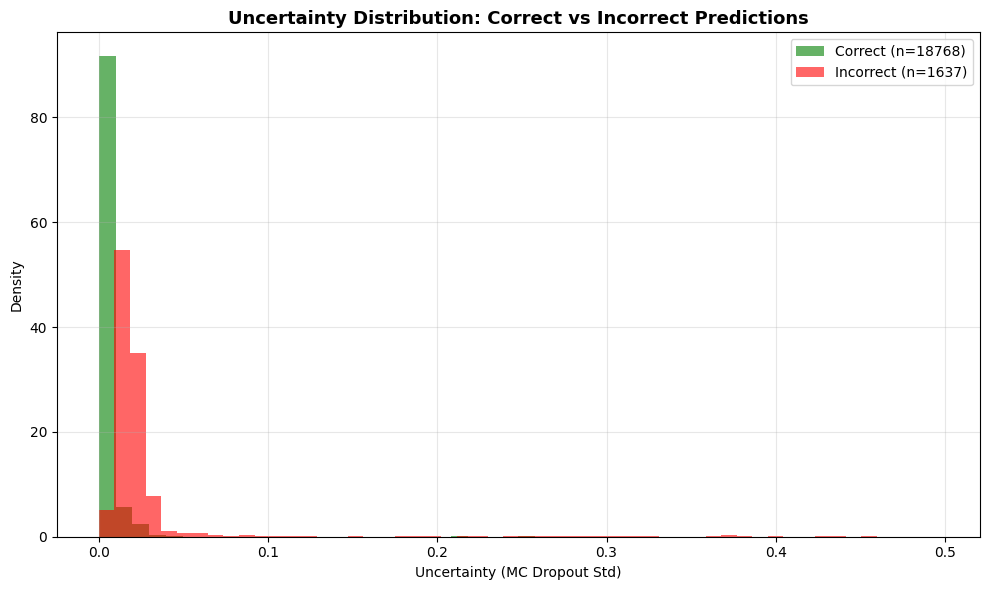

In [11]:
# Uncertainty distribution
plot_uncertainty_distribution(
    mc_uncertainties, true_labels, mc_predictions,
    save_path=os.path.join(RESULTS_DIR, 'exp4_uncertainty_dist.png')
)


In [12]:
# Hybrid system simulation
from sklearn.metrics import accuracy_score, f1_score

# For samples with low confidence, flag for LLM review
threshold = CONFIDENCE_THRESHOLD
mc_confidences = mc_mean_probs.max(axis=1)

high_conf_mask = mc_confidences >= threshold
low_conf_mask = ~high_conf_mask

print(f'\n=== Confidence-based Routing ===')
print(f'  Threshold: {threshold}')
print(f'  High confidence: {high_conf_mask.sum():,} ({high_conf_mask.mean()*100:.1f}%)')
print(f'  Low confidence -> LLM: {low_conf_mask.sum():,} ({low_conf_mask.mean()*100:.1f}%)')

# Accuracy on high-confidence predictions only
if high_conf_mask.sum() > 0:
    high_conf_acc = accuracy_score(true_labels[high_conf_mask], mc_predictions[high_conf_mask])
    print(f'\n  High-confidence accuracy: {high_conf_acc:.4f}')
    high_conf_f1 = f1_score(true_labels[high_conf_mask], mc_predictions[high_conf_mask])
    print(f'  High-confidence F1:       {high_conf_f1:.4f}')

if low_conf_mask.sum() > 0:
    low_conf_acc = accuracy_score(true_labels[low_conf_mask], mc_predictions[low_conf_mask])
    print(f'\n  Low-confidence accuracy:  {low_conf_acc:.4f}')
    print(f'  (These would be sent to LLM for verification)')



=== Confidence-based Routing ===
  Threshold: 0.7
  High confidence: 17,426 (85.4%)
  Low confidence -> LLM: 2,979 (14.6%)

  High-confidence accuracy: 0.9927
  High-confidence F1:       0.9922

  Low-confidence accuracy:  0.4931
  (These would be sent to LLM for verification)


In [13]:
# Final comparison table
exp4_results = {
    'RoBERTa (standard)': {
        'accuracy': roberta_metrics['accuracy'],
        'precision': roberta_metrics['precision'],
        'recall': roberta_metrics['recall'],
        'f1': roberta_metrics['f1']
    },
    'RoBERTa + MC Dropout': {
        'accuracy': mc_metrics['accuracy'],
        'precision': mc_metrics['precision'],
        'recall': mc_metrics['recall'],
        'f1': mc_metrics['f1']
    },
    'Hybrid (high-conf only)': {
        'accuracy': float(high_conf_acc) if high_conf_mask.sum() > 0 else 0,
        'precision': 0.0,
        'recall': 0.0,
        'f1': float(high_conf_f1) if high_conf_mask.sum() > 0 else 0
    }
}

print('\n=== EXPERIMENT 4: Uncertainty + LLM Hybrid ===')
compare_models_table(exp4_results)
save_metrics(exp4_results, os.path.join(RESULTS_DIR, 'exp4_hybrid.json'))



=== EXPERIMENT 4: Uncertainty + LLM Hybrid ===

  Model                            Accuracy  Precision     Recall         F1
──────────────────────────────────────────────────────────────────────
  RoBERTa (standard)                 0.9204     0.8569     0.9966     0.9215
  RoBERTa + MC Dropout               0.9198     0.8559     0.9968     0.9210
  Hybrid (high-conf only)            0.9927     0.0000     0.0000     0.9922

[OK] Metrics saved to: /content/project/results/exp4_hybrid.json


---
# Summary - All Experiments


In [14]:
print('\n' + '=' * 70)
print('  COMPLETE EXPERIMENTAL RESULTS')
print('=' * 70)

all_results = {}
for name, file in [('Exp1', 'exp1_baseline_comparison.json'),
                    ('Exp2', 'exp2_domain_adaptation.json'),
                    ('Exp3', 'exp3_calibration.json'),
                    ('Exp4', 'exp4_hybrid.json')]:
    path = os.path.join(RESULTS_DIR, file)
    if os.path.exists(path):
        data = load_metrics(path)
        print(f'\n--- {name} ---')
        print(json.dumps(data, indent=2))

print('\n' + '=' * 70)
print('  [OK] All experiments completed!')
print('  Results saved to:', RESULTS_DIR)
print('=' * 70)



  COMPLETE EXPERIMENTAL RESULTS

--- Exp1 ---
{
  "LR + TF-IDF": {
    "accuracy": 0.8926243567753002,
    "precision": 0.8806894416348436,
    "recall": 0.8918269230769231,
    "f1": 0.886223191566703
  },
  "RoBERTa (fine-tuned)": {
    "accuracy": 0.9203626562117129,
    "precision": 0.8569245978251101,
    "recall": 0.9965510033444817,
    "f1": 0.9214786180236773
  }
}

--- Exp2 ---
{
  "RoBERTa (general)": {
    "accuracy": 0.46890468022543497,
    "precision": 0.46890468022543497,
    "recall": 1.0,
    "f1": 0.6384412638040904
  },
  "RoBERTa (fine-tuned news)": {
    "accuracy": 0.9203626562117129,
    "precision": 0.8569245978251101,
    "recall": 0.9965510033444817,
    "f1": 0.9214786180236773
  }
}

--- Exp3 ---
{
  "optimal_temperature": 1.4977960586547852,
  "before": {
    "ECE": 0.012234774736527305,
    "Brier": 0.08406894439982877
  },
  "after": {
    "ECE": 0.00776472264602759,
    "Brier": 0.08301214197099929
  }
}

--- Exp4 ---
{
  "RoBERTa (standard)": {
    "a

## Key Findings

Tóm tắt kết quả thí nghiệm:

| Experiment | Kết luận |
|---|---|
| **Exp 1** | RoBERTa vượt trội so với baseline LR+TF-IDF |
| **Exp 2** | Fine-tuning trên news domain cải thiện đáng kể so với general RoBERTa |
| **Exp 3** | Temperature Scaling giảm ECE và Brier Score -> probability calibration tốt hơn |
| **Exp 4** | MC Dropout giúp ước lượng uncertainty; hybrid system tăng accuracy trên high-confidence predictions |

### Research Contributions
1. Đề xuất domain-adapted RoBERTa cho fake news detection
2. Áp dụng MC Dropout cho uncertainty estimation
3. Temperature Scaling cải thiện probability calibration
4. Hybrid system kết hợp RoBERTa + LLM verification
